# Experiment 1 - CNN Baseline

In this experiment we will first train a model using a simple Convolutional Neural Network (CNN) architecture on the Cats & Dogs dataset, following the keras tutorial BUT with pytorch instead of keras. This will serve as our baseline model for future experiments.

Then we will use the same architecture and train a model on the stanfords Dogs dataset, which is a more challenging dataset with 120 classes of dogs.

These 2 final models will be then saved and used as baselines for future experiments (e.g. using transfer learning, data augmentation, etc.).

## Dependencies

In [ ]:
%pip install torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install matplotlib numpy scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121


## Importing the libraries

These are most of the import needed for this experiment. We will import some more libraries if needed during the experiment.

In [ ]:
import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


## CNN - Cats & Dogs Dataset

As mentioned before, we will be implementin a simple CNN architecture for a model classifying the cats & dogs dataset. We will be following the [keras tutorial](https://keras.io/examples/vision/image_classification_from_scratch/) but with pytorch instead of keras.

Load the data in a directory named `PetImages`, it should have 2 subdirectories `Cat` and `Dog` each containing the respective images.

We will be first filtering out the corrupted images, then generate the dataset from the remaining images.

### Downloading the dataset

We will first download the dataset from the keras tutorial.

In [ ]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

!unzip -q kagglecatsanddogs_5340.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0   164M      0  0:00:04  0:00:04 --:--:--  161M


### Filtering out the corrupted images

In [ ]:
import os

def filter_corrupted_images(root_dir: str):
    num_skipped = 0
    for folder_name in ("Cat", "Dog"):
        folder_path = os.path.join(root_dir, folder_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                fobj = open(fpath, "rb")
                is_jfif = b"JFIF" in fobj.peek(10)
            finally:
                fobj.close()

            if not is_jfif:
                num_skipped += 1
                # Delete corrupted image
                os.remove(fpath)

    print(f"Deleted {num_skipped} images.")

filter_corrupted_images("./PetImages")

Deleted 1590 images.


### Generating the dataset

Now we can generate and load the dataset using ImageLoader and DataLoader from pytorch.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

def load_from_directory(
    root_dir: str,
    batch_size: int = 32,
    image_size: int = 180,
    test_split: float = 0.2,
    transforms: transforms.Compose = None,
):
    full_dataset = datasets.ImageFolder(root=root_dir, transform=transforms)

    # Getting test and train split
    test_size = int(test_split * len(full_dataset))
    train_size = len(full_dataset) - test_size

    # Generating splits for train and test datasets
    train_dataset, test_dataset = random_split(
        full_dataset, [train_size, test_size]
    )

    validation_size = int(0.2 * len(train_dataset))

    train_dataset, validation_dataset = random_split(
        train_dataset, [
            len(train_dataset) - validation_size, validation_size
        ]
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, validation_loader, full_dataset.classes

# Basic data transformation
transform = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.ToTensor(),
])

train_loader, test_loader, validation_loader, class_names = load_from_directory("./PetImages", transforms=transform)

print(f"Classes: {class_names}")
print(f"Number of batches in train loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(validation_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

Classes: ['Cat', 'Dog']
Number of batches in train loader: 469
Number of batches in validation loader: 118
Number of batches in test loader: 147


## Visualizing the data

Here are some helpers functions to visualize the data and the training process.

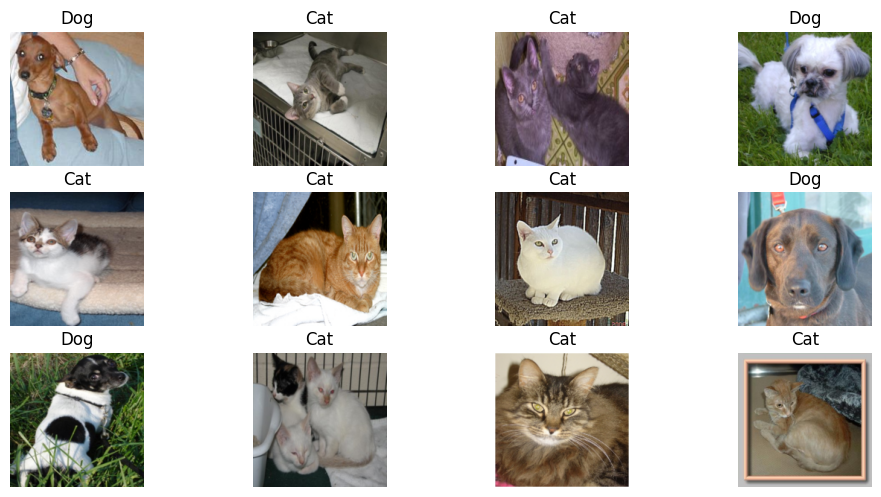

In [ ]:
def visualize_batch(loader: DataLoader, class_names: list) -> None:
    images, labels = next(iter(loader))
    images = images.numpy().transpose((0, 2, 3, 1))

    plt.figure(figsize=(12, 8))
    for i in range(12):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

visualize_batch(train_loader, class_names)

We can also get function to visualize the differents plots we will have.

In [ ]:
def plot_loss(train_losses: list, val_losses: list) -> None:
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.show()

def plot_accuracy(train_accuracies: list, val_accuracies: list) -> None:
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")

    plt.show()

### Using some data augmentation

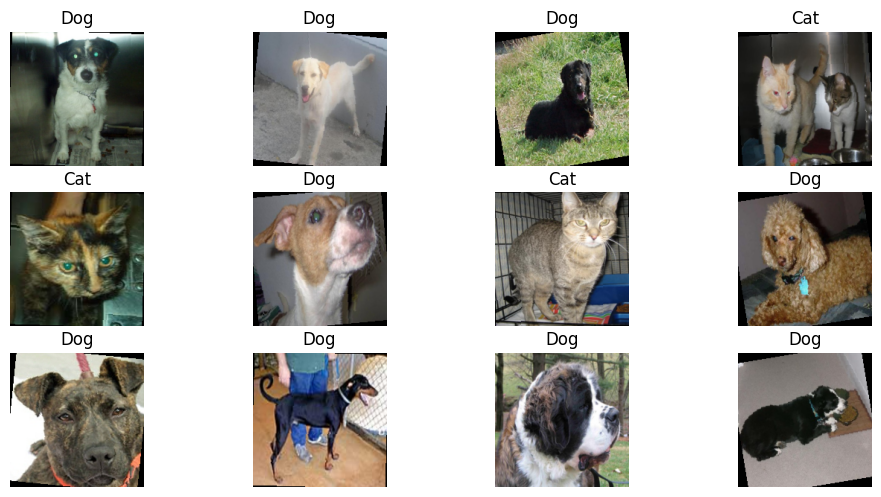

In [ ]:
data_augmentation_transforms = transforms.Compose([
    transforms.Resize((180, 180)),
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.RandomRotation(10), # 10 degrees rotation
    transforms.ToTensor(),
])

# Loading again with the new data augmentation transforms
train_loader, test_loader, validation_loader, class_names = load_from_directory("./PetImages", transforms=data_augmentation_transforms)
visualize_batch(train_loader, class_names)

### Building the CNN model

Now we can finally build our CNN model !

In [ ]:
## Understanding the architecture of the model: Separable Convolution and Residual Connections
class SeparableConv2d(nn.Module):
    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        kernel_size: int = 3,
        padding: int = 1,
    ):
        super().__init__()

        # Depthwise: one filter bank per input channel (no cross-channel mixing)
        self.depthwise = nn.Conv2d(
            in_ch,
            in_ch,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_ch, # No mixing of channels, each channel is convolved separately
            bias=False,
        )

        # Pointwise: 1x1 conv to mix channels and set output channels
        self.pointwise = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class ResidualSeparableConv2dBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReLU(),
            SeparableConv2d(in_ch=in_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.ReLU(),
            SeparableConv2d(in_ch=out_ch, out_ch=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),

            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Project residual to match both spatial size and channels
        self.proj_res = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=1,
            stride=2,
            padding=0,
            bias=False,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x) + self.proj_res(x)


class CatsAndDogsCNN(nn.Module):
    def __init__(self, num_classes: int = 2, in_channels: int = 3):
        super().__init__()

        # Entry block
        self.entry_block = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Residual blocks for channel progression 128 -> 256 -> 512 -> 728
        self.blocks = nn.Sequential(
            ResidualSeparableConv2dBlock(in_ch=128, out_ch=256),
            ResidualSeparableConv2dBlock(in_ch=256, out_ch=512),
            ResidualSeparableConv2dBlock(in_ch=512, out_ch=728),
        )

        out_units = 1 if num_classes == 2 else num_classes

        # Final layers
        self.final_layers = nn.Sequential(
            SeparableConv2d(in_ch=728, out_ch=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(1024, out_units), # logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # No scaling here because it is done by ToTensor() transform

        x = self.entry_block(x)
        x = self.blocks(x)
        x = self.final_layers(x)
        return x


model = CatsAndDogsCNN(num_classes=2).to(device)

### Train the model

Now that we can train our model, we have to first define our hyperparameters.


In [ ]:
EPOCHS = 25
LR = 1e-4

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
from typing import List, Tuple
from tqdm import tqdm

def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float]:
    model.train()
    total_loss = 0
    total_accuracy = 0

    for images, labels in tqdm(dataloader):
        images: torch.Tensor = images.to(device)
        labels: torch.Tensor = labels.to(device)

        # Forward pass
        outputs: torch.Tensor = model(images)
        loss: torch.Tensor = loss_fn(outputs.squeeze(), labels.float())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluate accuracy
        if outputs.shape[1] == 1:
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            total_accuracy += (preds == labels).sum().item()
        else:
            _, preds = torch.max(outputs, 1)
            total_accuracy += (preds == labels).sum().item()

        total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(dataloader.dataset)
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, avg_accuracy


def validate_model(
    model: nn.Module,
    val_dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    model.eval()
    total_loss = 0
    total_accuracy = 0

    with torch.inference_mode():
        for images, labels in tqdm(val_dataloader):
            images: torch.Tensor = images.to(device)
            labels: torch.Tensor = labels.to(device)

            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = loss_fn(outputs.squeeze(), labels.float())

            # Evaluate accuracy
            if outputs.shape[1] == 1:
                preds = (torch.sigmoid(outputs) >= 0.5).long()
                total_accuracy += (preds == labels).sum().item()
            else:
                _, preds = torch.max(outputs, 1)
                total_accuracy += (preds == labels).sum().item()

            total_loss += loss.item() * images.size(0)

    avg_accuracy = total_accuracy / len(val_dataloader.dataset)
    avg_loss = total_loss / len(val_dataloader.dataset)
    return avg_loss, avg_accuracy


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 25,
) -> Tuple[List[float], List[float], List[float], List[float]]:
    # Track the losses
    train_losses = []
    val_losses = []

    # Track the accuracy
    train_accuracies = []
    val_accuracies = []

    for epoch in tqdm(range(epochs)):
        print("\nTraining pass:")
        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        print("\nValidation pass:")
        val_loss, val_accuracy = validate_model(model, validation_loader, loss_fn, device)

        # Track the accuracies
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Track the losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
# Restart the loading of the data to reset the iterator
train_loader, test_loader, validation_loader, class_names = load_from_directory("./PetImages", transforms=data_augmentation_transforms, batch_size=128)

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
)

  0%|          | 0/25 [00:00<?, ?it/s]


Training pass:



100%|██████████| 118/118 [03:31<00:00,  1.79s/it]



Validation pass:



  4%|▍         | 1/25 [03:56<1:34:38, 236.59s/it]

...


100%|██████████| 118/118 [03:44<00:00,  1.90s/it]



Validation pass:



 20%|██        | 5/25 [20:37<1:22:57, 248.90s/it]

Epoch 5/25 - Train Loss: 0.3286 - Val Loss: 0.3475

Training pass:



 90%|████████▉ | 106/118 [03:23<00:22,  1.88s/it]

Ploting the results (accuracy and loss)

In [ ]:
print("Plotting the loss:")
plot_loss(train_losses, val_losses)

print()
print("Plotting the accuracy")
plot_accuracy(train_accuracies, val_accuracies)

### Run inference on new data

Now we can run our model on real data

In [ ]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
) -> float:
    model.eval()
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in tqdm(test_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).squeeze()
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    return accuracy

evaluate_model(model, test_loader, device)

We can also try to check and evaluate only one of them

In [ ]:
def predict_one(model: nn.Module, image: torch.Tensor, device: torch.device) -> str:
    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.inference_mode():
        output = torch.sigmoid(model(image).squeeze())

    pred_index = int(output >= 0.5)
    confidence = output.item() if pred_index == 1 else 1 - output.item()

    return f"{class_names[pred_index]} ({confidence * 100:.1f}%)"

def display_image(image: torch.Tensor) -> None:
    image = image.numpy().transpose((1, 2, 0))

    plt.imshow(image)
    plt.axis("off")
    plt.show()

image = next(iter(test_loader))[0][0]
display_image(image)
print(predict_one(model, image, device))

## Save the model

In [ ]:
def save_model(model: nn.Module, path: str) -> None:
    torch.save(model.state_dict(), path)

save_model(model, "model_cat_and_dogs_tuto.pth")